# 07 · TimesFM 3: a zero-shot foundation model

[TimesFM 3](https://research.google/blog/timesfm-3-a-zero-shot-foundation-model-for-multivariate-forecasting/) (Google Research, 2026) is a 330M-parameter decoder-only transformer. It was pre-trained on more than $10^{12}$ time points and forecasts series it has **never seen** with **no training**. It handles univariate and multivariate targets and covariates.

## How it works
1. **Patching.** Each series is cut into patches of $P = 32$ points. A residual MLP embeds each patch into a token: a context of $L$ points becomes $\lceil L/32\rceil$ tokens instead of $L$, so attention is cheap even for long contexts (up to 15,360 points).
2. **Per-series normalization** (RevIN-style): $\tilde y_t = (y_t - \mu)/\sigma$, inverted on the output, so scale doesn't matter.
3. **Alternating attention on a 2-D grid** (variate × time). Layers alternate between *causal* attention over time and *full* attention across variates. This lets the targets and covariates exchange information.
4. **Non-autoregressive decoding.** Contiguous Patch Masking lets the model output the whole horizon (in patches of 64) in **one forward pass**, so there are no compounding errors.
5. **Quantile head.** For every step it predicts 9 quantiles $q\in\{0.1,\dots,0.9\}$, trained with the pinball loss of notebook 02.

The model learns a generic prior over "how time series continue". It does **in-context** forecasting: the context window plays the role that training data plays for the other models.

In [1]:
%load_ext autoreload
%autoreload 2
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
from tsforecasting.data.data_loader import load_airline, load_jena, temporal_split
from tsforecasting.features.build_features import TARGET

try:
    df = load_jena()
except FileNotFoundError:  # first run: download + clean + features
    from tsforecasting.data import make_dataset
    from tsforecasting.features import build_features
    make_dataset.main(); build_features.main()
    df = load_jena()
y = df[TARGET]
airline = load_airline()
df.shape, airline.shape

((70128, 19), (144,))

In [3]:
import time
from tsforecasting.evaluation import backtest, score
from tsforecasting.models.foundation import get_device, load_timesfm, timesfm_forecast_fn
from tsforecasting.visualization.visualize import plot_backtest, plot_forecast

device = get_device()
print("device:", device)
t0 = time.time()
model = load_timesfm(device)  # first call downloads ~1.3 GB to the Hugging Face cache
print(f"loaded in {time.time() - t0:.1f}s,",
      f"{sum(p.numel() for p in model.model.parameters()) / 1e6:.0f}M parameters, quantiles {model.config.quantiles}")

device: cpu


loaded in 6.0s, 331M parameters, quantiles [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


## 1. Univariate zero-shot forecast

We give it 512 hours (~3 weeks) of temperature and ask for the next 96 hours. No fitting is involved.

inference 0.45s


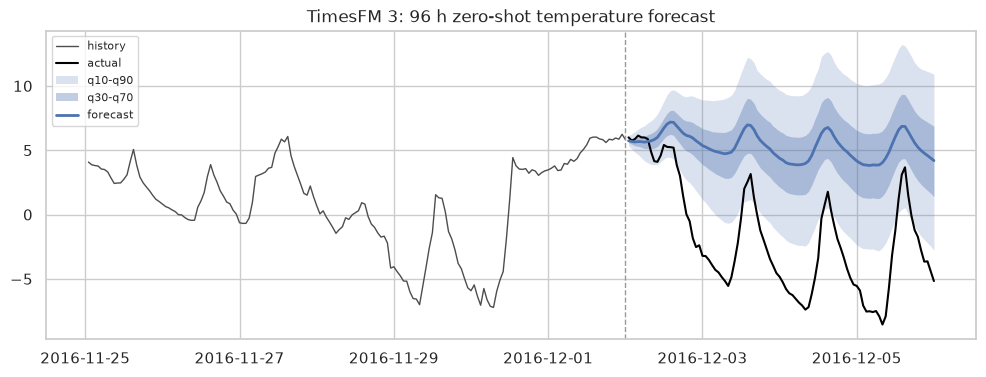

In [4]:
cut = len(y) - 24 * 30
ctx, actual = y.iloc[cut - 512 : cut], y.iloc[cut : cut + 96]
fn = timesfm_forecast_fn(model, context_len=512)
t0 = time.time(); fc = fn(ctx, 96); print(f"inference {time.time() - t0:.2f}s")
plot_forecast(ctx.iloc[-24 * 7 :], fc, actual, title="TimesFM 3: 96 h zero-shot temperature forecast");

## 2. How much context does it need?

More context gives the model more "in-context examples" of the daily cycle and the weather regime. We backtest 24 h forecasts over the test period for several context lengths $L$.

,mae,rmse,smape,mase,pinball,coverage80
64,2.382,3.631,34.946,0.909,0.953,0.764
128,2.316,3.323,33.648,0.884,0.929,0.738
256,1.994,2.656,31.949,0.761,0.770,0.780
512,1.992,2.581,32.057,0.760,0.762,0.764
1024,1.871,2.293,27.914,0.714,0.694,0.812
2048,1.852,2.301,28.148,0.707,0.694,0.806


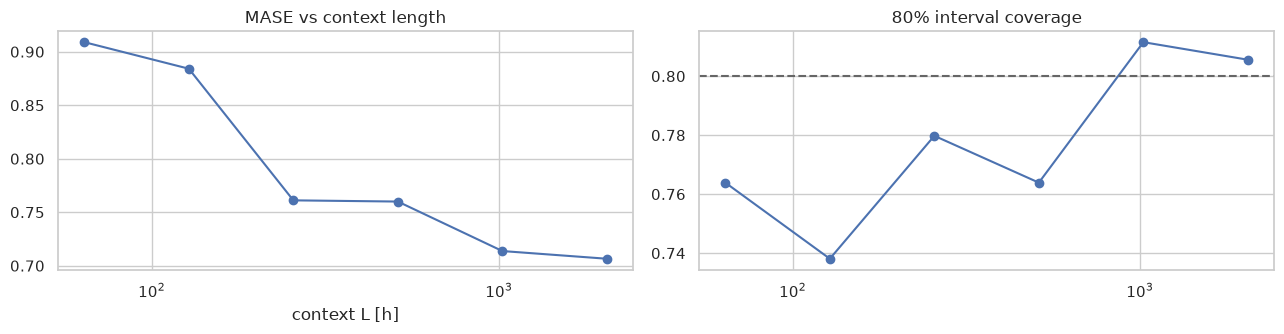

In [5]:
from tsforecasting.models.train_model import HORIZON, N_FOLDS

train_df, val_df, _ = temporal_split(df)
initial = len(train_df) + len(val_df)
step = (len(df) - initial - HORIZON) // N_FOLDS
ctx_scores = {L: score(backtest(timesfm_forecast_fn(model, context_len=L), y, initial, HORIZON, step, m=24))
              for L in [64, 128, 256, 512, 1024, 2048]}
cs = pd.DataFrame(ctx_scores).T
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
cs["mase"].plot(ax=axes[0], marker="o", logx=True, title="MASE vs context length"); axes[0].set_xlabel("context L [h]")
cs["coverage80"].plot(ax=axes[1], marker="o", logx=True, title="80% interval coverage"); axes[1].axhline(0.8, ls="--", c="0.4")
fig.tight_layout(); cs.round(3)

## 3. Calibration: are the quantiles honest?

For a calibrated forecaster, the fraction of observations below $\hat y^{(q)}$ should be $q$ for every $q$. Points on the diagonal mean calibrated, above it means too wide on that side, below it means too narrow.

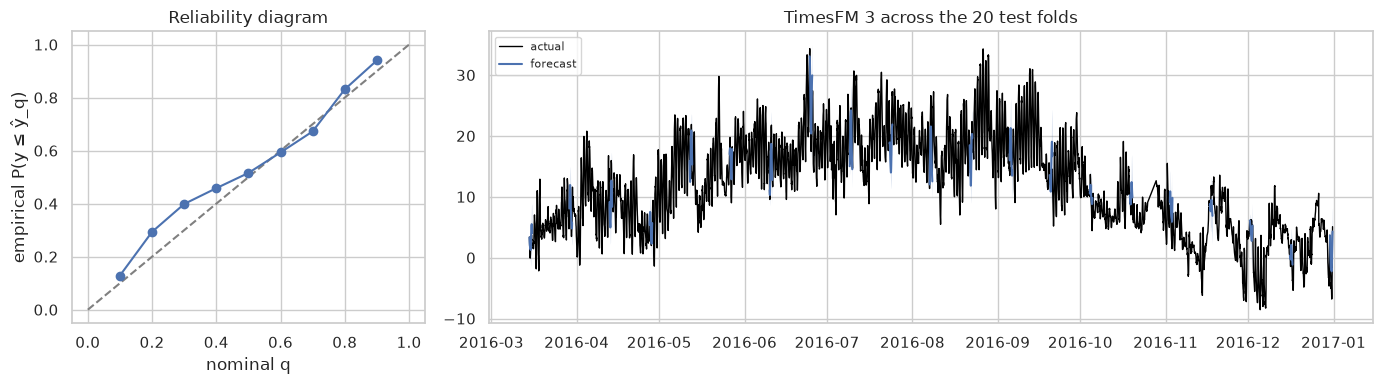

In [6]:
from tsforecasting.evaluation import QUANTILES, qcol

res = backtest(timesfm_forecast_fn(model, context_len=1024), y, initial, HORIZON, step, m=24)
emp = [np.mean(res.y <= res[qcol(q)]) for q in QUANTILES]
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1, 2.5]})
axes[0].plot([0, 1], [0, 1], "--", c="0.5"); axes[0].plot(QUANTILES, emp, "o-")
axes[0].set(xlabel="nominal q", ylabel="empirical P(y ≤ ŷ_q)", title="Reliability diagram")
plot_backtest(res, y, title="TimesFM 3 across the 20 test folds", ax=axes[1])
fig.tight_layout()

## 4. Multivariate forecasting

`predict_batch` accepts a $(k, L)$ array of $k$ target variates. Variate attention lets temperature, dew point and humidity inform each other. We compare against forecasting each variate alone.

,multivariate MAE,univariate MAE
T (degC),5.642,5.148
Tdew (degC),6.172,5.649
rh (%),6.313,5.860


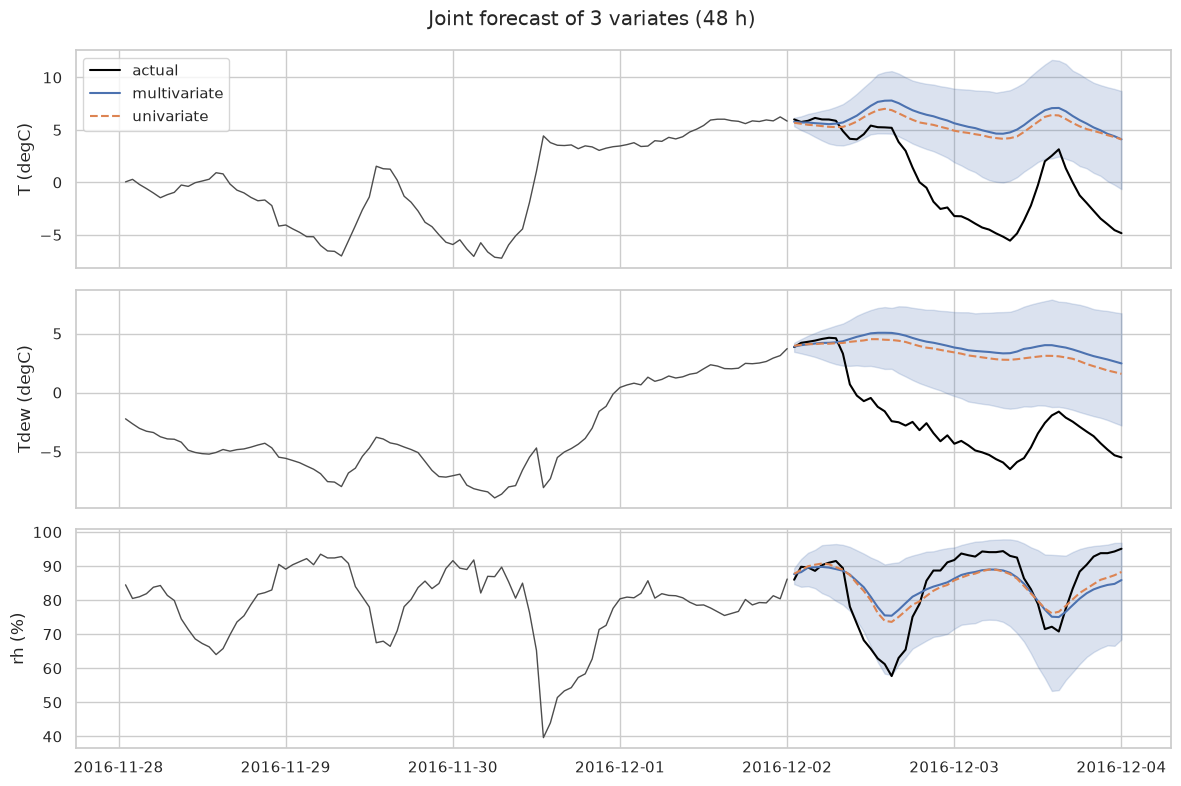

In [7]:
targets = ["T (degC)", "Tdew (degC)", "rh (%)"]
ctx_mv = df[targets].iloc[cut - 1024 : cut].to_numpy(np.float32).T
truth = df[targets].iloc[cut : cut + 48]
mv = list(model.predict_batch([ctx_mv], horizon=48, return_quantiles=True))[0]
uv = list(model.predict_batch(list(ctx_mv), horizon=48, return_quantiles=True))

fig, axes = plt.subplots(len(targets), 1, figsize=(12, 8), sharex=True)
for i, (ax, col) in enumerate(zip(axes, targets)):
    ax.plot(df[col].iloc[cut - 96 : cut], color="0.3", lw=1)
    ax.plot(truth.index, truth[col], color="black", lw=1.5, label="actual")
    ax.fill_between(truth.index, mv.quantiles[i, :, 0], mv.quantiles[i, :, -1], alpha=0.2, color="C0")
    ax.plot(truth.index, mv.forecast[i], color="C0", label="multivariate")
    ax.plot(truth.index, uv[i].forecast, color="C1", ls="--", label="univariate")
    ax.set_ylabel(col)
axes[0].legend(loc="upper left"); fig.suptitle("Joint forecast of 3 variates (48 h)"); fig.tight_layout()
pd.DataFrame({"multivariate MAE": np.abs(mv.forecast - truth.T.to_numpy()).mean(1),
              "univariate MAE": [np.abs(u.forecast - truth[c].to_numpy()).mean() for u, c in zip(uv, targets)]},
             index=targets).round(3)

## 5. Covariates

TimesFM 3 distinguishes two kinds of covariate:
- **past-only covariates** $(k, L)$: observed only up to now, e.g. pressure.
- **past-and-future covariates** $(k, L+H)$: known in advance, e.g. calendar features, holidays, promotions or weather forecasts.

For future-known covariates the model concatenates each context patch with the corresponding *future* patch (a look-ahead). Here we compare no covariates, calendar features, and calendar plus pressure/humidity as past-only covariates, over the full backtest.

,mae,rmse,smape,mase,pinball,coverage80
no covariates,1.871,2.293,27.914,0.714,0.694,0.812
calendar (future-known),1.844,2.358,30.267,0.703,0.694,0.806
calendar + past-only weather,1.821,2.408,29.424,0.695,0.690,0.831


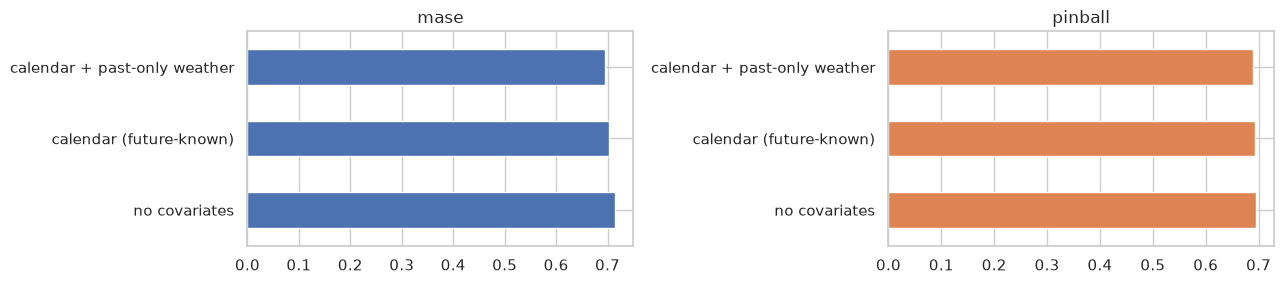

In [8]:
CAL = ["Day sin", "Day cos", "Year sin", "Year cos"]
PAST = ["p (mbar)", "rh (%)", "VPdef (mbar)"]
L = 1024

def cov_fn(y_train, h, X_train, X_future):
    ctx = y_train.to_numpy(np.float32)[-L:]
    pf = pd.concat([X_train[CAL].iloc[-L:], X_future[CAL]]).to_numpy(np.float32).T
    po = X_train[PAST].iloc[-L:].to_numpy(np.float32).T
    out = model.predict(ctx, horizon=h, past_only_covariates=po, past_future_covariates=pf, return_quantiles=True)
    return pd.DataFrame(out.quantiles, columns=[qcol(q) for q in QUANTILES]).assign(mean=out.forecast)

variants = {"no covariates": timesfm_forecast_fn(model, L),
            "calendar (future-known)": timesfm_forecast_fn(model, L, covariates=CAL),
            "calendar + past-only weather": cov_fn}
cov_scores = pd.DataFrame({k: score(backtest(f, y, initial, HORIZON, step, X=df, m=24)) for k, f in variants.items()}).T
cov_scores[["mase", "pinball"]].plot.barh(subplots=True, layout=(1, 2), figsize=(13, 3), legend=False, sharex=False)
plt.tight_layout(); cov_scores.round(3)

## 6. Zero-shot on a classic: airline passengers

The airline series is monthly, short (144 points) and multiplicative: a completely different regime from hourly weather. How does a model that was never fitted to it compare with the hand-crafted SARIMA from notebook 03?

,mae,rmse,smape,mase,pinball,coverage80
seasonal naive,36.440,41.701,9.122,1.239,NaN,NaN
SARIMA airline,18.371,23.408,4.521,0.622,NaN,NaN
TimesFM 3 zero-shot,17.400,20.914,4.332,0.592,6.622,0.714


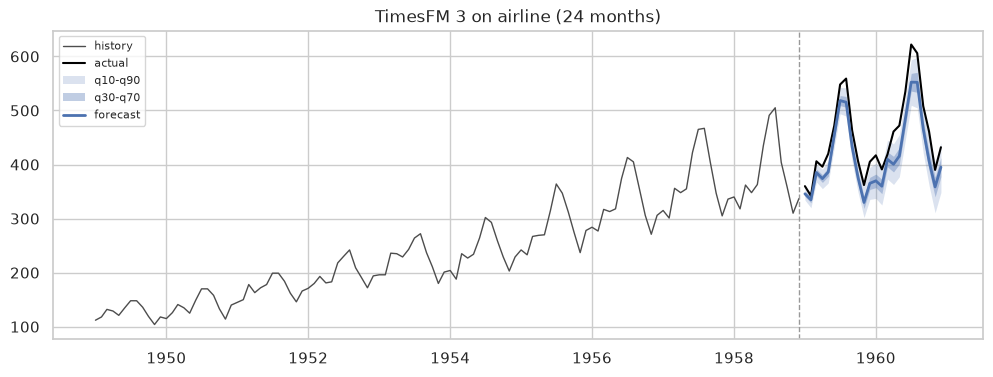

In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tsforecasting.models.baselines import seasonal_naive

def sarima_fn(y_, h, *_):
    r = SARIMAX(np.log(y_), order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
    return pd.DataFrame({"mean": np.exp(r.forecast(h)).to_numpy()})

air = {k: backtest(f, airline, initial=96, horizon=12, step=6, m=12) for k, f in
       {"seasonal naive": seasonal_naive(12), "SARIMA airline": sarima_fn,
        "TimesFM 3 zero-shot": timesfm_forecast_fn(model, context_len=512)}.items()}
display(pd.DataFrame({k: score(r) for k, r in air.items()}).T.round(3))
train_a, test_a = airline.iloc[:-24], airline.iloc[-24:]
plot_forecast(train_a, timesfm_forecast_fn(model)(train_a, 24), test_a, title="TimesFM 3 on airline (24 months)");

## 7. Hardware: CPU vs this machine's GPU

The test machine has a **GTX 960M**: Maxwell (compute capability 5.0), 2 GB of VRAM, and a driver that supports up to CUDA 12.7.
- The default PyPI torch wheel targets CUDA 13, which this driver can't run. Recent CUDA 12.8+ wheels also dropped Maxwell kernels altogether.
- The only route is a **cu126 wheel with torch ≤ 2.7**: `uv pip install "torch==2.7.*" --index-url https://download.pytorch.org/whl/cu126`.
- The model weights take ~1.3 GB in fp32, which barely fits in 2 GB, and Maxwell has no fast fp16. Expect a modest speed-up at best.

`get_device()` returns `"cuda"` only if a kernel *actually runs*, so the cell below is always safe. Run `uv sync` to go back to the default CPU setup.

In [10]:
import torch

def bench(dev, n=5):
    m = model if str(model.device) == dev else load_timesfm(dev)
    ctxs = [y.iloc[i * 100 : i * 100 + 1024].to_numpy(np.float32) for i in range(8)]
    list(m.predict_batch(ctxs[:1], horizon=24))  # warm-up
    t0 = time.time()
    for _ in range(n):
        list(m.predict_batch(ctxs, horizon=24))
    return (time.time() - t0) / n

timings = {"cpu": bench("cpu")}
if get_device() == "cuda":
    torch.cuda.reset_peak_memory_stats()
    timings["cuda"] = bench("cuda")
    print(f"peak VRAM: {torch.cuda.max_memory_allocated() / 2**30:.2f} GB")
else:
    print("CUDA not usable with the installed torch build -> CPU only (see markdown above)")
pd.Series(timings, name="seconds per batch of 8 series (L=1024, H=24)").round(3)

CUDA not usable with the installed torch build -> CPU only (see markdown above)


cpu    2.365
Name: seconds per batch of 8 series (L=1024, H=24), dtype: float64

## Takeaways
- With **zero training**, TimesFM 3 is competitive with models tuned on 6 years of this exact series, and its 80% intervals are close to nominal.
- Context length is its "training set size". On Jena, MASE improves up to $L\approx1024$ h (~6 weeks) and then plateaus.
- Covariates and multivariate inputs are first-class, but their benefit is data-dependent. Here covariates helped only slightly, and in the single 48 h example the joint forecast was *worse* than univariate. Always backtest.
- Inference is cheap on CPU (well under a second per series), so foundation models make strong default baselines.